<a href="https://colab.research.google.com/github/Jacinto2727/Loan_Report/blob/main/Understanding_financial_loan_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Loading Financial_loan.csv Dataset

In [ ]:
import pandas as pd
df = pd.read_csv("/content/financial_loan.csv")
df.head()


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


###Displaying information on columns,count and respective Datatypes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

###Representing text of loan status charged off and paid into numerical values 1 and 0


In [ ]:
df['default_flag'] = df['loan_status'].apply(lambda x: 1 if str(x).strip().lower() == 'charged off' else 0)
result = (
    df.groupby(['emp_length', 'purpose'])
      .agg(
          total_loans=('loan_status', 'count'),
          charged_off=('default_flag', 'sum')
      )
      .assign(default_percentage=lambda x: round((x['charged_off'] / x['total_loans']) * 100, 2))
      .reset_index()
      .sort_values(by='default_percentage', ascending=False)
)






In [ ]:
result

,emp_length,purpose,total_loans,charged_off,default_percentage
122,8 years,renewable_energy,2,1,50.00
66,4 years,renewable_energy,7,3,42.86
52,3 years,renewable_energy,11,4,36.36
110,7 years,vacation,14,5,35.71
123,8 years,small business,62,18,29.03
...,...,...,...,...,...
94,6 years,renewable_energy,8,0,0.00
136,9 years,renewable_energy,4,0,0.00
133,9 years,medical,15,0,0.00
139,9 years,wedding,19,0,0.00


In [ ]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment,default_flag
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009,1
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939,0
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522,1
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911,0
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835,0


### Categorizing emp_length into <1 year, 1-5 year, 6-10 year and 10> year

In [ ]:
def categorize_emp_length(emp_length):
    if emp_length == '< 1 year':
        return '<1 year'
    elif emp_length in ['1 year', '2 years', '3 years', '4 years', '5 years']:
        return '1-5 year'
    elif emp_length in ['6 years', '7 years', '8 years', '9 years', '10 years']:
        return '6-10 year'
    elif emp_length == '10+ years':
        return '10+year'
    else:
        return 'Unknown' # Handle potential missing or unexpected values

df['emp_length_category'] = df['emp_length'].apply(categorize_emp_length)

In [ ]:
df[['emp_length','emp_length_category']].head(10)

,emp_length,emp_length_category
0,< 1 year,<1 year
1,9 years,6-10 year
2,4 years,1-5 year
3,< 1 year,<1 year
4,10+ years,10+year
5,3 years,1-5 year
6,10+ years,10+year
7,10+ years,10+year
8,10+ years,10+year
9,10+ years,10+year


In [ ]:
df.drop(columns=['emp_length'],inplace=True)

###Analyzing default percentage or charged_off loans on the basis of loan purpose

In [ ]:
df.groupby(by='purpose').agg(total_loans=('loan_status', 'count'),charged_off=('default_flag', 'sum')).assign(default_percentage=lambda x: round((x['charged_off'] / x['total_loans']) * 100, 2)) .sort_values(by='default_percentage', ascending=False)

,total_loans,charged_off,default_percentage
purpose,,,
small business,1776,455,25.62
renewable_energy,94,17,18.09
educational,315,50,15.87
house,366,57,15.57
other,3824,587,15.35
moving,559,84,15.03
medical,667,100,14.99
Debt consolidation,18214,2651,14.55
vacation,352,50,14.20


###Conclusion: Loans taken for the purpose of small business and renewable energy show high default rates

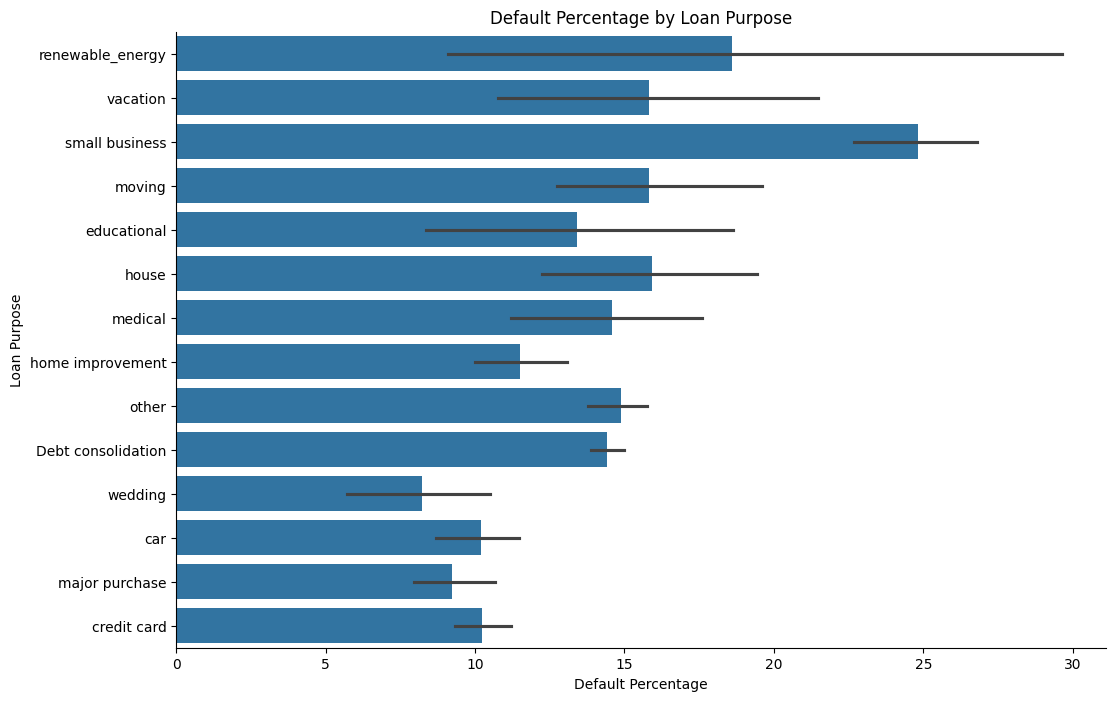

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by default percentage for better visualization
result_sorted = result.sort_values(by='default_percentage', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='default_percentage', y='purpose', data=result_sorted)
plt.title('Default Percentage by Loan Purpose')
plt.xlabel('Default Percentage')
plt.ylabel('Loan Purpose')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

###Analyzing Default rates by the term length of the loans taken

In [ ]:
df.groupby(by='emp_length_category').agg(total_loans=('loan_status', 'count'),charged_off=('default_flag', 'sum')).assign(default_percentage=lambda x: round((x['charged_off'] / x['total_loans']) * 100, 2)) .sort_values(by='default_percentage', ascending=False)

,total_loans,charged_off,default_percentage
emp_length_category,,,
10+year,8870,1322,14.90
<1 year,4575,631,13.79
6-10 year,6731,923,13.71
1-5 year,18400,2457,13.35


###Loans of tenure 1-5 years have maximum number of defaults of 46.1%

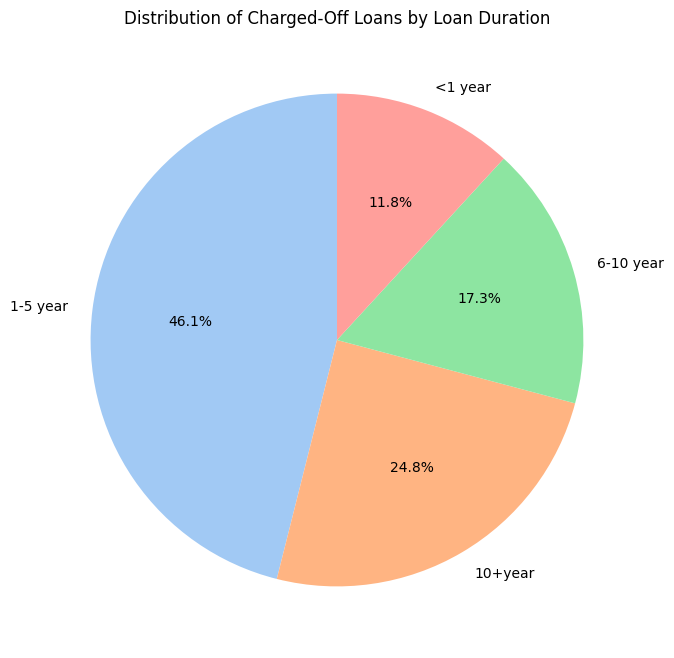

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the desired duration buckets
filtered_df = df[df['emp_length_category'].isin(['1-5 year', '6-10 year','<1 year','10+year'])]

# Group by duration bucket and calculate charged off loans
charged_off_by_duration = filtered_df.groupby('emp_length_category')['default_flag'].sum().reset_index()

# Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(charged_off_by_duration['default_flag'], labels=charged_off_by_duration['emp_length_category'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel')[0:len(charged_off_by_duration)])
plt.title('Distribution of Charged-Off Loans by Loan Duration')
plt.show()

###Understanding the relationship between Debt-to-Income (DTI) Ratio and default_percentage

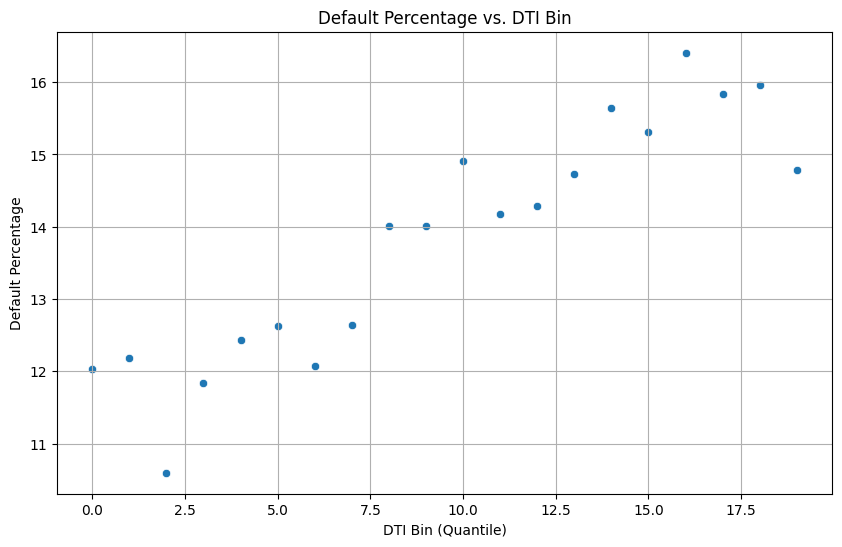

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame and it contains 'dti' and 'default_flag' columns.
# First, we need to calculate the default percentage for different bins of DTI.
# We can use pandas qcut to create bins based on quantiles of the 'dti' column.
# Let's create 20 bins for example.

df['dti_bin'] = pd.qcut(df['dti'], q=20, labels=False, duplicates='drop')

# Now group by the DTI bins and calculate the default percentage
dti_default = df.groupby('dti_bin')['default_flag'].agg(['count', 'sum']).reset_index()
dti_default = dti_default.rename(columns={'count': 'total_loans', 'sum': 'charged_off'})
dti_default['default_percentage'] = (dti_default['charged_off'] / dti_default['total_loans']) * 100

# Now create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='dti_bin', y='default_percentage', data=dti_default)
plt.title('Default Percentage vs. DTI Bin')
plt.xlabel('DTI Bin (Quantile)')
plt.ylabel('Default Percentage')
plt.grid(True)
plt.show()

### Understanding there is a positive correlation between DTI and Default percentage meaning an increase in DTI will lead to higher chances of loans getting default

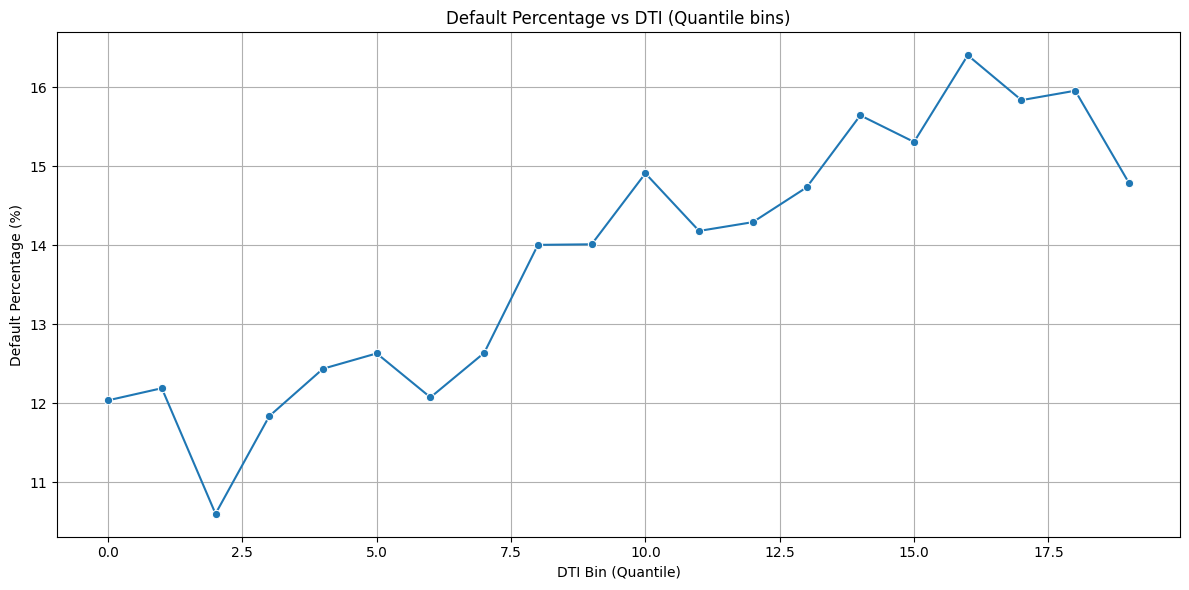

In [ ]:

df['dti_bin'] = pd.qcut(df['dti'], q=20, labels=False, duplicates='drop')

# Step 2: Group by DTI bins and calculate total loans & defaults
dti_default = (
    df.groupby('dti_bin')['default_flag']
      .agg(['count', 'sum'])
      .reset_index()
      .rename(columns={'count': 'total_loans', 'sum': 'charged_off'})
)

# Step 3: Calculate default percentage
dti_default['default_percentage'] = (
    dti_default['charged_off'] / dti_default['total_loans']
) * 100

# Step 4: Plot the Default % vs DTI Range
plt.figure(figsize=(12, 6))
sns.lineplot(x='dti_bin', y='default_percentage', data=dti_default, marker='o')

# Optional: make x-axis readable
# plt.xticks(rotation=45, ha='right') # Not needed with numerical bins

plt.title('Default Percentage vs DTI (Quantile bins)')
plt.xlabel('DTI Bin (Quantile)')
plt.ylabel('Default Percentage (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Analyzing the distribution of charged off loans by their verification status

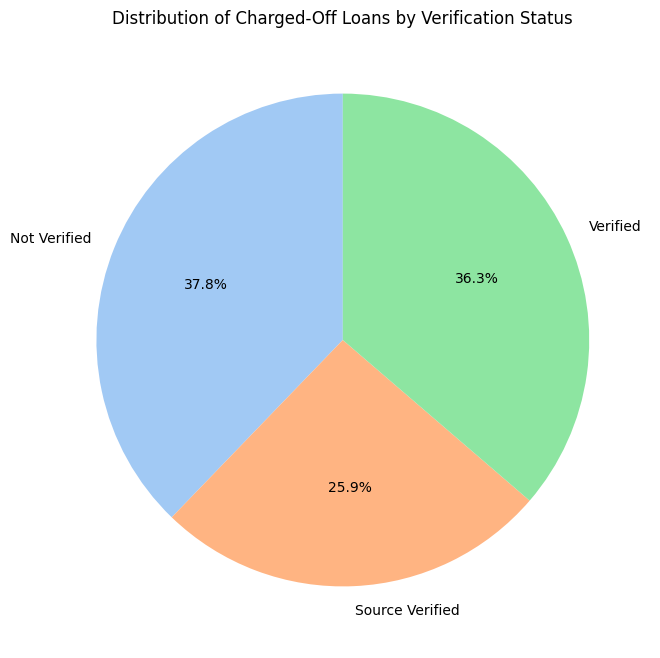

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by verification_status and calculate charged off loans
charged_off_by_verification = df.groupby('verification_status')['default_flag'].sum().reset_index()

# Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(charged_off_by_verification['default_flag'], labels=charged_off_by_verification['verification_status'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel')[0:len(charged_off_by_verification)])
plt.title('Distribution of Charged-Off Loans by Verification Status')
plt.show()